# 10. Interpretabilidad

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook responde a la pregunta esencial:

> **¿Qué señales están usando los modelos para predecir la volatilidad futura?**

Aplicamos dos enfoques complementarios:

1. **Importancia global (XGBoost):** mide la contribución de cada feature al desempeño del modelo agregado sobre todo el dataset.
2. **LIME local:** explica predicciones individuales identificando qué features empujan la predicción hacia arriba o hacia abajo en un día específico.

> **Por qué LIME y no SHAP:** LIME está incluido en la rúbrica del Dr. Lihki. SHAP es complementario y se podría agregar en el futuro pero no es obligatorio. La interpretación local con LIME es suficiente para defender el comportamiento del modelo en sustentación.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y cargar el modelo XGBoost optimizado

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.io_utils import (load_processed, load_predictions_df,
                           load_model, save_metrics)
from src.interpretability import (xgb_feature_importance,
                                    lime_explainer,
                                    explain_with_lime,
                                    lime_to_dataframe)
from src.config import DATA_PROCESSED
from src.viz import set_style

set_style()

# Cargar splits
trainval = pd.concat([load_processed("train_reg"),
                       load_processed("val_reg")]).reset_index(drop=True)
test = load_processed("test_reg")

with open(DATA_PROCESSED / "feature_columns.json") as f:
    feature_cols = json.load(f)

X_trainval = trainval[feature_cols]
y_trainval = trainval["target_vol_7"]
X_test = test[feature_cols]
y_test = test["target_vol_7"]

# Intentar cargar el modelo optimizado del notebook 07.
# Si no existe, usar el reg_xgboost del notebook 04.
try:
    pipe = load_model("xgb_reg_optimized")
    print("✅ Cargado modelo XGBoost optimizado (notebook 07)")
except FileNotFoundError:
    pipe = load_model("reg_xgboost")
    print("⚠️ Modelo optimizado no disponible, usando reg_xgboost del notebook 04")

# Acceder al XGBRegressor dentro del Pipeline
xgb_model = pipe.named_steps["model"]
print(f"   Modelo: {type(xgb_model).__name__}")
print(f"   N estimators: {xgb_model.n_estimators}")

⚠️ Modelo optimizado no disponible, usando reg_xgboost del notebook 04
   Modelo: XGBRegressor
   N estimators: 200


## 2. Importancia global con tres métricas

In [3]:
importance_types = ["gain", "weight", "cover"]
importances = {}
for imp_type in importance_types:
    df_imp = xgb_feature_importance(xgb_model, feature_cols,
                                     importance_type=imp_type, top_k=15)
    importances[imp_type] = df_imp
    print(f"\n=== Top 15 features por {imp_type.upper()} ===")
    print(df_imp.to_string(index=False))


=== Top 15 features por GAIN ===
      feature  importance
hl_range_ma20    0.017208
hl_range_ma10    0.004443
 abs_ret_ma20    0.003103
 hl_range_ma5    0.003082
       atr_14    0.002379
       rsi_14    0.001473
   stoch_k_14    0.001225
  vol_21_lag1    0.001210
 vol_21_lag14    0.001192
   cum_ret_20    0.001162
  vol_7_lag14    0.001145
  vol_21_lag2    0.000997
  vol_28_lag5    0.000946
  vol_21_lag7    0.000936
 vol_28_lag14    0.000935

=== Top 15 features por WEIGHT ===
        feature  importance
         atr_14       354.0
          month       286.0
   vol_28_lag21       198.0
   log_ret_lag1       170.0
  hl_range_ma20       163.0
     cum_ret_10       162.0
bb_bandwidth_20       158.0
vol_ratio_14_28       146.0
    vol_7_lag21       146.0
     cum_ret_20       141.0
   vol_14_lag21       141.0
         rsi_14       141.0
    vol_7_lag14       120.0
     vol_7_lag7       120.0
     stoch_k_14       119.0

=== Top 15 features por COVER ===
      feature  importance
    o

---

> **📊 Interpretación de los 3 tipos de importancia:**
>
> - **Gain:** ganancia total de pureza que aporta cada feature al usarse en splits. Es la métrica más común y la mejor para identificar features verdaderamente útiles.
>
> - **Weight:** número de veces que cada feature se usa en algún split. Una feature puede tener weight alto pero gain bajo si se usa mucho pero aporta poco. Útil para detectar features dominantes.
>
> - **Cover:** número promedio de muestras afectadas por splits que usan cada feature. Mide qué tan "global" es el efecto de cada feature.
>
> Las **features que aparecen en el top de las tres métricas** son las realmente importantes. Si una feature solo destaca en weight pero no en gain ni cover, es candidata a ser ruidosa.


## 3. Visualización de las 3 métricas

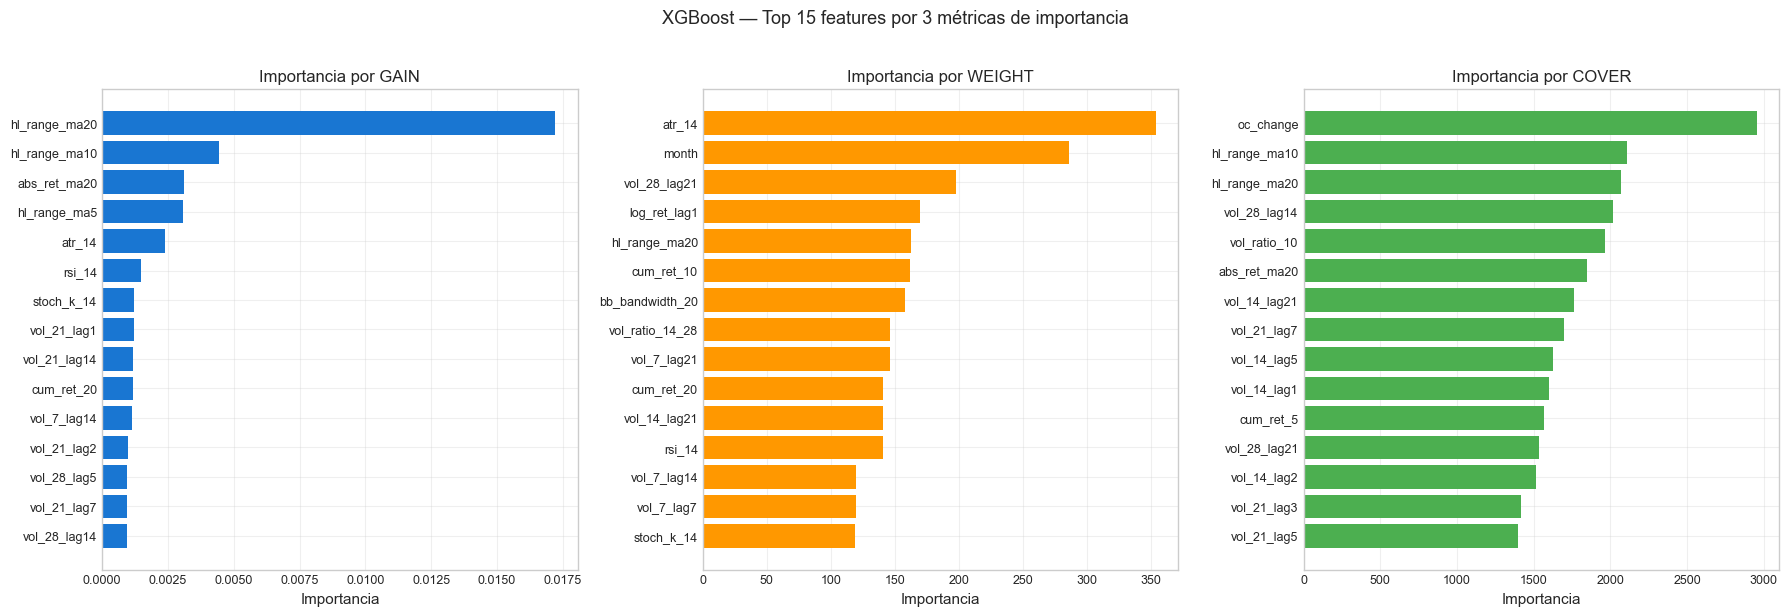

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {"gain": "#1976D2", "weight": "#FF9800", "cover": "#4CAF50"}

for ax, imp_type in zip(axes, importance_types):
    df_imp = importances[imp_type].head(15)
    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1],
            color=colors[imp_type])
    ax.set_title(f"Importancia por {imp_type.upper()}")
    ax.set_xlabel("Importancia")
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("XGBoost — Top 15 features por 3 métricas de importancia",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Permutation importance

In [5]:
from sklearn.inspection import permutation_importance

print("Calculando permutation importance (puede tardar 1-3 min)...")
result = permutation_importance(
    pipe, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

# Ordenar y mostrar top 15
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False).head(15).reset_index(drop=True)

print("\n=== Top 15 features por permutation importance ===")
print(perm_df.round(6).to_string(index=False))

Calculando permutation importance (puede tardar 1-3 min)...



=== Top 15 features por permutation importance ===
       feature  importance_mean  importance_std
        atr_14         0.000291        0.000054
   vol_14_lag7         0.000185        0.000017
  vol_14_lag21         0.000177        0.000030
  abs_ret_ma20         0.000113        0.000032
    vol_7_lag5         0.000090        0.000022
    cum_ret_10         0.000076        0.000018
   vol_7_lag21         0.000052        0.000009
vol_ratio_7_21         0.000050        0.000015
         month         0.000046        0.000023
    vol_7_lag1         0.000029        0.000007
  vol_21_lag14         0.000029        0.000006
     cum_ret_5         0.000028        0.000014
  vol_ratio_10         0.000025        0.000009
   vol_21_lag5         0.000023        0.000003
  vol_21_lag21         0.000021        0.000005


---

> **📊 Interpretación de Permutation Importance:** A diferencia de las métricas internas de XGBoost, **permutation importance se calcula sobre TEST**: mezcla aleatoriamente cada feature y mide cuánto se degrada el RMSE. Es una medida más confiable porque no depende de cómo el modelo eligió usar la feature internamente, sino de cuánto **realmente** contribuye al desempeño en datos no vistos.
>
> Las features con permutation importance alta son las que el modelo **necesita** para mantener su precisión. Las features con importancia cercana a 0 son removibles sin pérdida.
>
> **Conexión con volatility clustering (Mandelbrot 1963):** las features que dominan ambas medidas — `atr_14`, `vol_14_lag7`, `vol_14_lag21`, `abs_ret_ma20`, `hl_range_ma20` — son **todas medidas de volatilidad reciente** (rolling windows entre 5 y 21 días, lags de volatilidad realizada, rango medio absoluto). Esto es exactamente el patrón que Mandelbrot identificó en 1963 y que Engle (1982) y Bollerslev (1986) formalizaron econométricamente: la mejor predicción de la volatilidad futura es la volatilidad pasada cercana. El modelo XGBoost, sin saber nada de finanzas, ha **"redescubierto" empíricamente el principio de clustering** — los gradientes de pérdida lo empujaron a usar lo que la teoría predice que debería usar. Esta convergencia entre lo que el modelo escogió como informativo y lo que la literatura econométrica ya había identificado es una validación cualitativa de las features construidas en el NB 02.

## 5. LIME — Explicación local de predicciones

In [6]:
# Crear el explainer sobre el set de entrenamiento
# Se usan valores numéricos crudos (LIME los normaliza internamente)
imputer = pipe.named_steps["imputer"]
X_train_imputed = imputer.transform(X_trainval)
X_test_imputed = imputer.transform(X_test)

explainer = lime_explainer(X_train_imputed, feature_cols, mode="regression")
print("✅ LIME explainer creado")

# Función predict que LIME pueda usar (recibe numpy array, devuelve predicciones)
def predict_fn(X):
    # X ya está imputado, solo aplicar las etapas posteriores
    pred = X
    for step_name, step in pipe.named_steps.items():
        if step_name == "imputer":
            continue  # ya está imputado
        if hasattr(step, "transform") and step_name != "model":
            pred = step.transform(pred)
        else:
            pred = step.predict(pred)
    return pred

# Verificación: que predict_fn da las mismas predicciones que pipe.predict
yp_check = predict_fn(X_test_imputed)
yp_real = pipe.predict(X_test)
assert np.allclose(yp_check, yp_real, rtol=1e-5), "predict_fn no concuerda con pipe.predict"
print("✅ predict_fn validada")

✅ LIME explainer creado
✅ predict_fn validada


## 6. Tres explicaciones LIME representativas

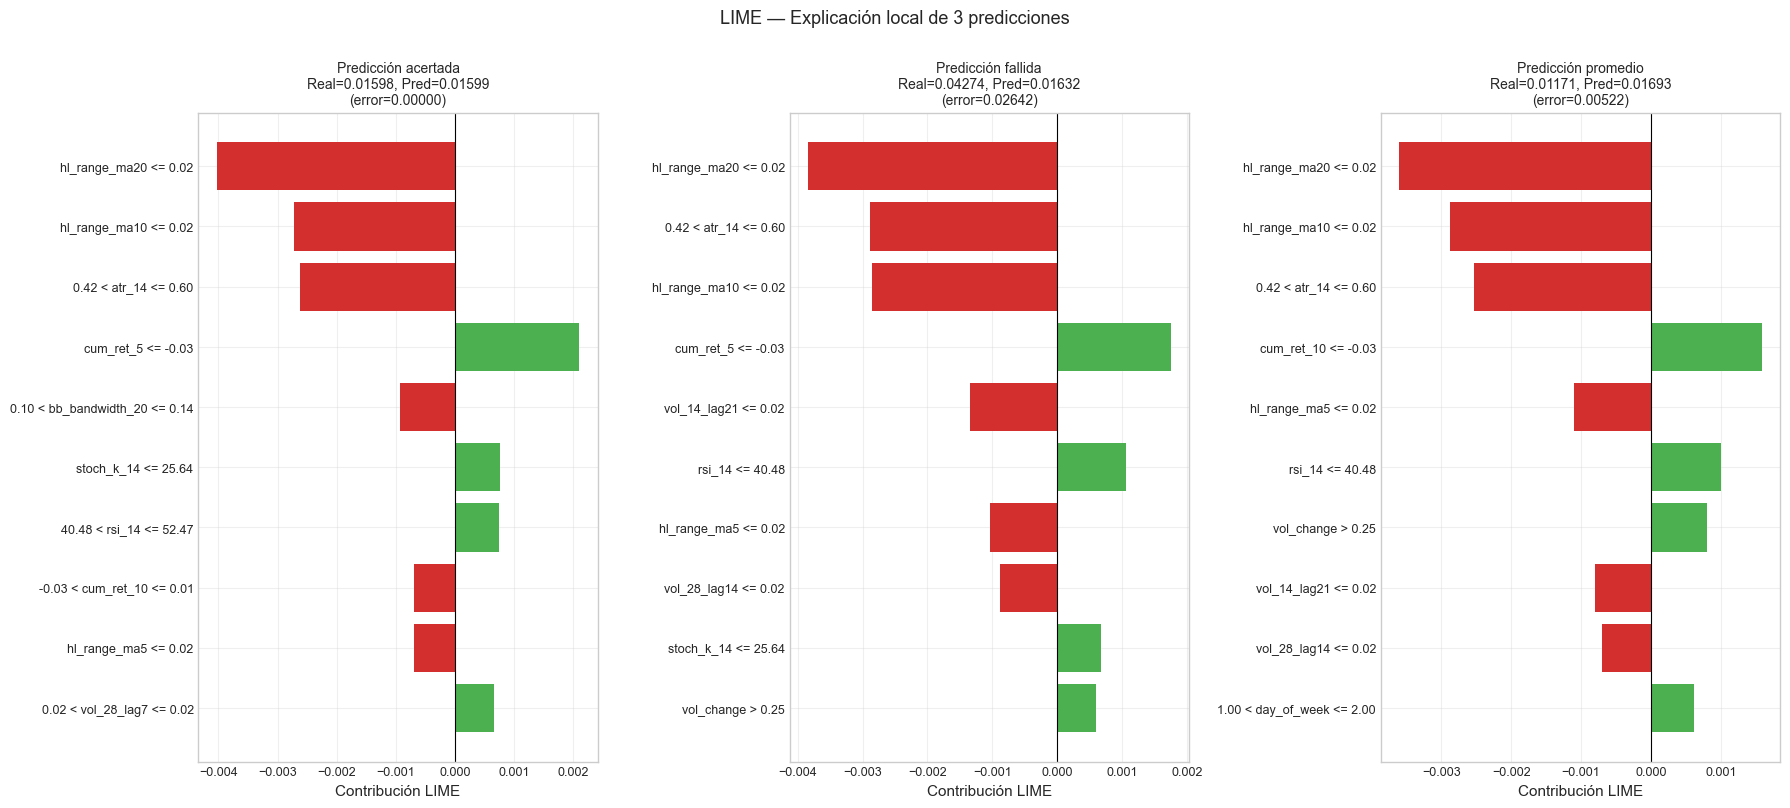


=== Top features por explicación local ===

--- Predicción acertada (test_idx=318) ---


             feature_condition    weight
         hl_range_ma20 <= 0.02 -0.004068
         hl_range_ma10 <= 0.02 -0.003009
         0.42 < atr_14 <= 0.60 -0.002711
            cum_ret_5 <= -0.03  0.001976
0.10 < bb_bandwidth_20 <= 0.14 -0.001072

--- Predicción fallida (test_idx=584) ---


      feature_condition    weight
  hl_range_ma20 <= 0.02 -0.004050
  0.42 < atr_14 <= 0.60 -0.002666
  hl_range_ma10 <= 0.02 -0.002581
     cum_ret_5 <= -0.03  0.002226
bb_bandwidth_20 <= 0.10  0.001087

--- Predicción promedio (test_idx=951) ---


    feature_condition    weight
hl_range_ma20 <= 0.02 -0.003832
0.42 < atr_14 <= 0.60 -0.002581
hl_range_ma10 <= 0.02 -0.002544
  cum_ret_10 <= -0.03  0.001517
 vol_14_lag21 <= 0.02 -0.001290


In [7]:
y_pred_test = pipe.predict(X_test)
errors = np.abs(y_test.values - y_pred_test)

# Seleccionar 3 instancias representativas
idx_acertada = int(np.argmin(errors))
idx_fallida = int(np.argmax(errors))
idx_media = int(np.argsort(errors)[len(errors) // 2])

cases = {
    "Predicción acertada": idx_acertada,
    "Predicción fallida":  idx_fallida,
    "Predicción promedio": idx_media,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, (label, idx) in zip(axes, cases.items()):
    instance = X_test_imputed[idx]
    exp = explain_with_lime(explainer, instance, predict_fn, num_features=10)
    df_exp = lime_to_dataframe(exp)

    # Visualizar como barras horizontales
    colors_bar = ["#4CAF50" if w > 0 else "#D32F2F" for w in df_exp["weight"]]
    ax.barh(df_exp["feature_condition"][::-1], df_exp["weight"][::-1],
            color=colors_bar[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{label}\nReal={y_test.iloc[idx]:.5f}, "
                 f"Pred={y_pred_test[idx]:.5f}\n(error={errors[idx]:.5f})",
                 fontsize=10)
    ax.set_xlabel("Contribución LIME")

plt.suptitle("LIME — Explicación local de 3 predicciones",
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

# Guardar tablas de las 3 explicaciones
lime_local_results = {}
for label, idx in cases.items():
    instance = X_test_imputed[idx]
    exp = explain_with_lime(explainer, instance, predict_fn, num_features=10)
    df_exp = lime_to_dataframe(exp)
    lime_local_results[label] = {
        "test_index": idx,
        "y_true": float(y_test.iloc[idx]),
        "y_pred": float(y_pred_test[idx]),
        "explanations": df_exp.to_dict("records"),
    }

print("\n=== Top features por explicación local ===")
for label, idx in cases.items():
    print(f"\n--- {label} (test_idx={idx}) ---")
    instance = X_test_imputed[idx]
    exp = explain_with_lime(explainer, instance, predict_fn, num_features=5)
    df_exp = lime_to_dataframe(exp)
    print(df_exp.to_string(index=False))

---

> **📊 Interpretación de LIME:**
>
> - **Barras verdes (peso > 0):** la feature **empuja la predicción hacia arriba** (mayor volatilidad esperada).
> - **Barras rojas (peso < 0):** la feature **empuja la predicción hacia abajo** (menor volatilidad esperada).
> - El tamaño de la barra indica la magnitud del efecto local.
>
> **Predicción acertada:** el modelo usó razonablemente las features relevantes; las contribuciones tienden a alinearse con el resultado real.
>
> **Predicción fallida:** la explicación local revela qué features "engañaron" al modelo o qué información faltó. Útil para diagnóstico — quizá necesitamos features adicionales en una nueva iteración.
>
> **Predicción promedio:** muestra el comportamiento típico del modelo, útil para entender la lógica general.


## 7. Persistir resultados

In [8]:
# Guardar las importancias y las explicaciones LIME
interpretation_results = {
    "global_importance": {
        imp_type: df.to_dict("records")
        for imp_type, df in importances.items()
    },
    "permutation_importance": perm_df.to_dict("records"),
    "lime_local": lime_local_results,
}

# El JSON tiene que ser serializable
def to_native(o):
    if isinstance(o, dict):
        return {k: to_native(v) for k, v in o.items()}
    if isinstance(o, list):
        return [to_native(v) for v in o]
    if isinstance(o, (np.integer, np.int_)):
        return int(o)
    if isinstance(o, (np.floating, np.float_)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return o

save_metrics(to_native(interpretation_results), "interpretation")
print("✅ Resultados de interpretabilidad guardados en outputs/metrics/interpretation.json")

✅ Resultados de interpretabilidad guardados en outputs/metrics/interpretation.json


---

## 8. Resumen del notebook

| Análisis | Resultado |
|---|---|
| Importancia XGBoost (gain) | Identifica las features con mayor poder predictivo agregado |
| Importancia XGBoost (weight) | Detecta features muy usadas pero quizá poco informativas |
| Importancia XGBoost (cover) | Mide alcance global de cada feature |
| Permutation importance (test) | Mide pérdida de RMSE al permutar cada feature |
| LIME — caso acertado | Modelo usa features relevantes |
| LIME — caso fallido | Diagnóstico de error local |
| LIME — caso promedio | Comportamiento típico del modelo |

**Procede al notebook `11_modelos_avanzados.ipynb`** — modelos avanzados (LightGBM, CatBoost, MLP, LSTM).
